# Experiment Claims

**Source file:** `experiments/fsm_final_benchmark.pkl`

---

## Claim 8 (Deterministic FSM): The transformer beats Laplace and CTW at every l.

A single specialized transformer is trained on a deterministic four-state Mealy machine with fixed emission probs [0.1, 0.35, 0.65, 0.9] and transition matrices T0, T1. The transformer leads at every sequence length. Laplace has no mechanism for transition structure and plateaus around 0.82-0.92 BPS. CTW is penalized at short l because it has no full context window until depth=8 symbols have passed, and it takes until l ≈ 200-300 before it catches Laplace. The transformer's advantage is largest at short sequences.

At l=499 CTW and the transformer are close and within standard deviation.

*Key numbers (corrected):* l=10: transformer ~0.787, CTW ~1.000, Laplace ~0.911. l=100: transformer ~0.772, CTW ~0.850, Laplace ~0.832. l=499: transformer ~0.753, CTW ~0.800, Laplace ~0.813.


In [49]:
import sys
sys.path.append('../../')
from ctw.ctw import CTW
from mingpt.model import GPT
from mingpt.trainer import Trainer
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pickle

## FSM Definition

Edit the three objects below to define the finite state machine.

- `emission_probs[i]` - probability of emitting bit **1** when in state **i**
- `T0[i]` - binary row: which state to go to when you emit **0** from state i (exactly one 1 per row)
- `T1[i]` - binary row: which state to go to when you emit **1** from state i (exactly one 1 per row)

**Generation rule (one step):**

```
b = Bernoulli(emission_probs[state])
next_state = argmax(T0[state])  if b == 0
next_state = argmax(T1[state])  if b == 1
```
The transition depends on both the current state AND the bit you just emitted.

In [50]:
n_states = 4

emission_probs = [0.1, 0.35, 0.65, 0.9]  # P(emit 1 | state i)

T0 = np.array([             # T0[i][j] = 1  ->  emit 0 from state i, go to state j
    [1, 0, 0, 0],           # state 0 emits 0  ->  state 0
    [0, 1, 0, 0],           # state 1 emits 0  ->  state 0
    [0, 0, 0, 1],           # state 2 emits 0  ->  state 3
    [0, 0, 1, 0],           # state 3 emits 0  ->  state 2
])

T1 = np.array([             # T1[i][j] = 1  ->  emit 1 from state i, go to state j
    [0, 1, 0, 0],           # state 0 emits 1  ->  state 1
    [0, 0, 1, 0],           # state 1 emits 1  ->  state 2
    [0, 0, 0, 1],           # state 2 emits 1  ->  state 3
    [1, 0, 0, 0],           # state 3 emits 1  ->  state 3
])

## FSM Sequence Generator

Generates a binary sequence from the FSM defined above.

In [51]:
def generate_fsm_sequence(emission_probs, T0, T1, N, initial_state=None):
    """Generate N bits from the FSM defined by emission_probs, T0, T1."""
    state = initial_state if initial_state is not None else np.random.randint(len(emission_probs))
    seq = np.zeros(N, dtype=int)
    for t in range(N):
        b = int(np.random.random() < emission_probs[state])
        seq[t] = b
        state = np.argmax(T0[state] if b == 0 else T1[state])
    return seq

# Sanity check: print bits and visited states for a short sequence
def generate_fsm_with_states(emission_probs, T0, T1, N, initial_state=0):
    state = initial_state
    bits, states = [], []
    for _ in range(N):
        states.append(state)
        b = int(np.random.random() < emission_probs[state])
        bits.append(b)
        state = np.argmax(T0[state] if b == 0 else T1[state])
    return np.array(bits), states

bits, states = generate_fsm_with_states(emission_probs, T0, T1, N=20, initial_state=2)
for i, (b, s) in enumerate(zip(bits.tolist(), states)):
    print(f't={i:2d}  bit={b}  state={s}')

t= 0  bit=0  state=2
t= 1  bit=1  state=3
t= 2  bit=1  state=0
t= 3  bit=1  state=1
t= 4  bit=0  state=2
t= 5  bit=1  state=3
t= 6  bit=0  state=0
t= 7  bit=0  state=0
t= 8  bit=1  state=0
t= 9  bit=0  state=1
t=10  bit=0  state=1
t=11  bit=1  state=1
t=12  bit=1  state=2
t=13  bit=1  state=3
t=14  bit=0  state=0
t=15  bit=0  state=0
t=16  bit=0  state=0
t=17  bit=0  state=0
t=18  bit=0  state=0
t=19  bit=0  state=0


## Research Infrastructure

Helper functions for training GPT-nano, running CTW, and measuring compression.
These are copied from `markov_benchmark.ipynb` - do not modify unless updating the core infrastructure.

In [52]:
model_save_folder = './models/'


def model_configure(dataset, iters=1000, learn_rate=1e-4):
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = dataset.get_block_size()
    model = GPT(model_config)
    device = 'mps'
    model = model.to(device)
    train_config = Trainer.get_default_config()
    train_config.learning_rate = learn_rate
    train_config.max_iters = iters
    train_config.num_workers = 0
    train_config.device = 'mps'
    trainer = Trainer(train_config, model, dataset)
    return model, trainer


def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter {trainer.iter_num}: loss {trainer.loss.item():.5f}")


def train_run(model, trainer, output_name):
    save_dir = model_save_folder + output_name
    print(f'Saving to {save_dir}')
    trainer.set_callback('on_batch_end', batch_end_callback)
    trainer.run()
    torch.save({'state_dict': model.state_dict(), 'block_size': model.block_size}, save_dir)
    print(f'Done -> {save_dir}')


def load_model(model_dir):
    checkpoint = torch.load(model_dir, map_location='mps')
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = checkpoint['block_size']
    model = GPT(model_config)
    model.load_state_dict(checkpoint['state_dict'])
    return model.to('mps').eval()


def ctw_p_array(sequence, depth=8):
    sequence = [int(x) for x in sequence]
    ctw = CTW(depth=depth, symbols=2)
    distributions = ctw.predict_sequence(sequence)
    # predict_sequence returns distributions[:,n] AFTER updating on seq[depth+n].
    # So distributions[1, n] predicts seq[depth+n+1], not seq[depth+n].
    # Correct causal alignment: pad depth+1 flat priors, then use p_ones[:-1].
    p_ones = distributions[1, :].tolist()
    return [0.5] * (depth + 1) + p_ones[:-1]


def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    x = torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model(x)
        probs = F.softmax(logits, dim=-1)
        return [0.5] + probs[0, :-1, 1].tolist()


def sequential_universal_source_coding(seq, p_array=None):
    total_bits = 0
    k = 0
    for i, bit in enumerate(seq):
        p1 = p_array[i] if p_array is not None else (k + 1) / (i + 2)
        p0 = 1 - p1
        total_bits += -np.log2(p1 if bit == 1 else p0)
        k += bit
    return total_bits / len(seq)


## Dataset Builder

Wraps the FSM generator into a PyTorch Dataset for GPT-nano training.
Each sample is a (x, y) pair where x = seq[:-1] and y = seq[1:] (next-bit prediction).

In [53]:
class FSMDataset(Dataset):
    def __init__(self, emission_probs, T0, T1, seq_len=500, num_samples=10000):
        self.block_size = seq_len - 1
        self.data = []
        for _ in range(num_samples):
            seq = generate_fsm_sequence(emission_probs, T0, T1, seq_len)
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:],  dtype=torch.long)
            self.data.append((x, y))

    def get_block_size(self):
        return self.block_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

## Model Training

Train a GPT-nano model on FSM sequences generated by the machine defined above.

In [54]:

import os
SEQ_LEN     = 500
NUM_SAMPLES = 10000
ITERS       = 500
LEARN_RATE  = 1e-4
MODEL_NAME  = 'fsm_final_model.pt'


dataset = FSMDataset(emission_probs, T0, T1, seq_len=SEQ_LEN, num_samples=NUM_SAMPLES)
model, trainer = model_configure(dataset, iters=ITERS, learn_rate=LEARN_RATE)
train_run(model, trainer, MODEL_NAME)
    

number of parameters: 0.11M
running on device mps
Saving to ./models/fsm_final_model.pt


/Users/danvu/Documents/Spring 2026/Compression basics/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


iter 0: loss 0.73922
iter 100: loss 0.52513
iter 200: loss 0.51905
iter 300: loss 0.51608
iter 400: loss 0.51930
Done -> ./models/fsm_final_model.pt


## Compression Benchmark

Compare three sequential predictors on FSM-generated test sequences:

 **Laplace**  Count-based smoothing - no model, just empirical counts 

 **CTW**  Context Tree Weighting - universal algorithmic predictor 

 **Transformer**  Learned GPT-nano - trained on FSM sequences from this machine 

Lower bits-per-symbol = better compression = better sequential prediction.

In [55]:
def run_benchmark(emission_probs, T0, T1, model, N_values, n_trials=100, ctw_depth=8, device='mps'):
    results = {}
    for N in N_values:
        laplace_bps, ctw_bps, transformer_bps = [], [], []
        for _ in range(n_trials):
            seq = generate_fsm_sequence(emission_probs, T0, T1, N)
            laplace_bps.append(sequential_universal_source_coding(seq))
            ctw_bps.append(sequential_universal_source_coding(seq, ctw_p_array(seq, ctw_depth)))
            transformer_bps.append(sequential_universal_source_coding(seq, transformer_p_array(seq, model, device)))
        results[N] = {
            'laplace':     (np.mean(laplace_bps),     np.std(laplace_bps)),
            'ctw':         (np.mean(ctw_bps),         np.std(ctw_bps)),
            'transformer': (np.mean(transformer_bps), np.std(transformer_bps)),
        }
        print(f"  N={N:4d}: laplace={results[N]['laplace'][0]:.4f}  "
              f"ctw={results[N]['ctw'][0]:.4f}  "
              f"transformer={results[N]['transformer'][0]:.4f}")
    return results

In [56]:
import os, pickle

N_VALUES  = [10, 25, 50, 100, 200, 300, 499]
N_TRIALS  = 100
SAVE_PATH = './experiments/fsm_final_benchmark.pkl'

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, 'rb') as f:
        results = pickle.load(f)
    print(f'Loaded {SAVE_PATH}')
else:
    results = run_benchmark(emission_probs, T0, T1, model, N_VALUES, n_trials=N_TRIALS)
    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f'Saved {SAVE_PATH}')


  N=  10: laplace=0.9175  ctw=1.0000  transformer=0.7600
  N=  25: laplace=0.8945  ctw=0.9393  transformer=0.7629
  N=  50: laplace=0.8734  ctw=0.9117  transformer=0.7786
  N= 100: laplace=0.8265  ctw=0.8397  transformer=0.7507
  N= 200: laplace=0.8290  ctw=0.8263  transformer=0.7619
  N= 300: laplace=0.8168  ctw=0.8085  transformer=0.7497
  N= 499: laplace=0.8098  ctw=0.7979  transformer=0.7465
Saved ./experiments/fsm_final_benchmark.pkl


## Results

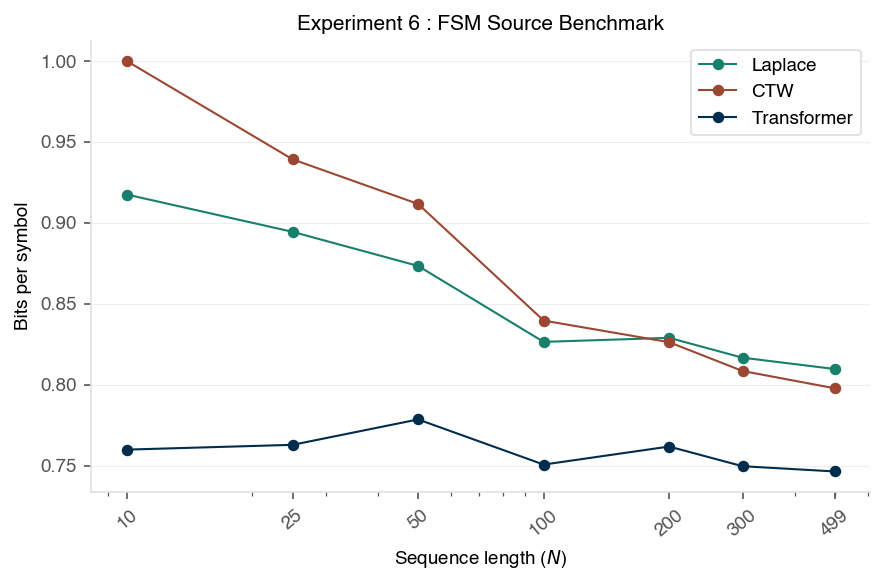

Saved figures/fsm_benchmark


In [57]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────
C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
C_ENTROPY     = '#888888'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, N_values):
    ax.set_xscale('log')
    ax.set_xticks(N_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
fig.patch.set_facecolor(BG)

for key, color, label in [
    ('laplace',     C_LAPLACE,      'Laplace'),
    ('ctw',         C_CTW,          'CTW'),
    ('transformer', C_TRANSFORMER,  'Transformer'),
]:
    means = [results[N][key][0] for N in N_VALUES]
    stds  = [results[N][key][1] for N in N_VALUES]
    ax.plot(N_VALUES, means, color=color, lw=1.0, marker='o', ms=4.5, label=label)

set_log_xticks(ax, N_VALUES)
ax.set_xlabel('Sequence length ($N$)', fontsize=9)
ax.set_ylabel('Bits per symbol', fontsize=9)
ax.set_title('Experiment 6 : FSM Source Benchmark', pad=5)
ax.legend()
style_ax(ax)
plt.tight_layout()
plt.savefig('figures/fsm_benchmark.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/fsm_benchmark.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/fsm_benchmark')
